# Plot Simulation Results

Unified plotting & reporting for the Qt–Ft simulations. Set everything in the **Settings** cell, then run the **Run** cell — it makes the plots **and** prints the summary **and** writes the data/table exports automatically.

Pick one of three modes:
- `MODE = "single"` — one finished single run (`trajectory.h5` under `Simulation_Files_Single_Runs/`)
- `MODE = "ensemble"` — one ensemble directory under `Different_Particle_Ratios/`
- `MODE = "comparison"` — several ensembles overlaid

Outputs go to a `Plots/` folder inside the run/ensemble directory (or `Plots_Comparison_<labels>/` for comparisons).

## 1. Imports

In [23]:
import importlib
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import qtft
import qtft.config, qtft.system, qtft.engine
import qtft.analysis as analysis
import qtft.plotting as plotting
import qtft.comparison as ae
from qtft import SimulationConfig

# Dev helper: reload submodules after editing the qtft .py files (restart the kernel for deep changes).
for _m in (qtft.config, qtft.system, qtft.engine, qtft.analysis, qtft.plotting,
           qtft.comparison, qtft):
    importlib.reload(_m)
analysis = qtft.analysis
plotting = qtft.plotting
ae       = qtft.comparison
from qtft import SimulationConfig

print("qtft plotting/analysis/comparison modules loaded")

qtft plotting/analysis/comparison modules loaded


## 2. Settings

In [24]:
# ============================================================
# PLOT SETTINGS  —  choose what to plot and where the data lives
# ============================================================
MODE = "single"   # "single" | "ensemble" | "comparison"

BASE_DIR = "Simulation_Files_Single_Runs"   # parent folder for ensembles / comparisons

# ----- MODE == "single": one finished single run -----
SINGLE_RUN_DIR = os.path.join(
    BASE_DIR, "200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_phases2_kon1e-06_aggsteps750000_koff1.2e-08_deaggsteps750000_dt1us_1.5s_loops", 
)
SINGLE_H5     = None   # None -> auto-detect (<run>.h5, or trajectory_combined.h5 for phased runs)
SINGLE_CONFIG = None   # None -> auto-detect (<run>_config.json inside SINGLE_RUN_DIR)

# ----- MODE == "ensemble": one ensemble directory -----
ENSEMBLE_DIR = os.path.join(
    BASE_DIR, "200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_kon1e-06_dt1us_750ms_loops",
)

# ----- MODE == "comparison": several ensembles, {label: directory} -----
ENSEMBLES_TO_COMPARE = {
    "200 Qt 200 Ft":  os.path.join(BASE_DIR, "200Qt_200Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us"),
}

# ----- Plot options -----
SHOW_INDIVIDUAL = False   # ensemble panel: overlay individual replica traces
SHOW_BANDS      = None    # comparison: None = auto (bands for <= 3 ensembles); True/False to force
# Structural/composition analysis reads particle positions from the recorded trajectory,
# so it works whether or not a run stored the optional particles observable (default off;
# see particles_observable_stride in Run_Simulation).
STRIDE          = 1       # single: frame stride for structural/composition analysis
EXPORT_XYZ      = False   # single: also export an OVITO .xyz (can be large/slow)

print(f"MODE = {MODE!r}")

MODE = 'single'


## 3. Run — plots, summary & data export

✓ Configuration loaded from Simulation_Files_Single_Runs/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_phases2_kon1e-06_aggsteps750000_koff1.2e-08_deaggsteps750000_dt1us_1.5s_loops/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_phases2_kon1e-06_aggsteps750000_koff1.2e-08_deaggsteps750000_dt1us_1.5s_loops_config.json
Single run: Simulation_Files_Single_Runs/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_phases2_kon1e-06_aggsteps750000_koff1.2e-08_deaggsteps750000_dt1us_1.5s_loops/trajectory_combined.h5
Plots/exports -> Simulation_Files_Single_Runs/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_phases2_kon1e-06_aggsteps750000_koff1.2e-08_deaggsteps750000_dt1us_1.5s_loops/Plots/

  Bond counting: Method 1 (topology.edges) - exact count
  Extracting frame data for morphology analysis...
    Using trajectory.read() for data extraction (particles observable not available)
    Reading trajectory frames...


  Morphology: 100%|██████████| 15001/15001 [01:07<00:00, 223.07frame/s] 


  Extracting frame data for contact analysis...
    Using trajectory.read() for data extraction (particles observable not available)
    Reading trajectory frames...


  Contacts: 100%|██████████| 15001/15001 [00:07<00:00, 2026.41frame/s]


  Extracting frame data for composition analysis...
    Using trajectory.read() for data extraction (particles observable not available)
    Reading trajectory frames...


...

  Extracting frame data for spatial analysis...
    Using trajectory.read() for data extraction (particles observable not available)
    Reading trajectory frames...


  Spatial: 100%|██████████| 15001/15001 [04:23<00:00, 56.86frame/s]  



Generating ensemble thesis panel...
✓ Saved panel to Simulation_Files_Single_Runs/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_phases2_kon1e-06_aggsteps750000_koff1.2e-08_deaggsteps750000_dt1us_1.5s_loops/Plots/run_panel.svg
✓ Saved panel to Simulation_Files_Single_Runs/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_phases2_kon1e-06_aggsteps750000_koff1.2e-08_deaggsteps750000_dt1us_1.5s_loops/Plots/run_panel.png
  Bond counting: Method 1 (topology.edges) - exact count
  Bond counting: Method 1 (topology.edges) - exact count
✓ Saved: Simulation_Files_Single_Runs/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_phases2_kon1e-06_aggsteps750000_koff1.2e-08_deaggsteps750000_dt1us_1.5s_loops/Plots/kinetics.svg
  Bond counting: Method 1 (topology.edges) - exact count


/home/befe/readdySimulations/Qt_Ft_Simulation_Github/qtft/plotting.py:795: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  print(f"  Warning: Unexpected error in particle counts plot: {e}")


✓ Saved plot to Simulation_Files_Single_Runs/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_phases2_kon1e-06_aggsteps750000_koff1.2e-08_deaggsteps750000_dt1us_1.5s_loops/Plots/observables.svg


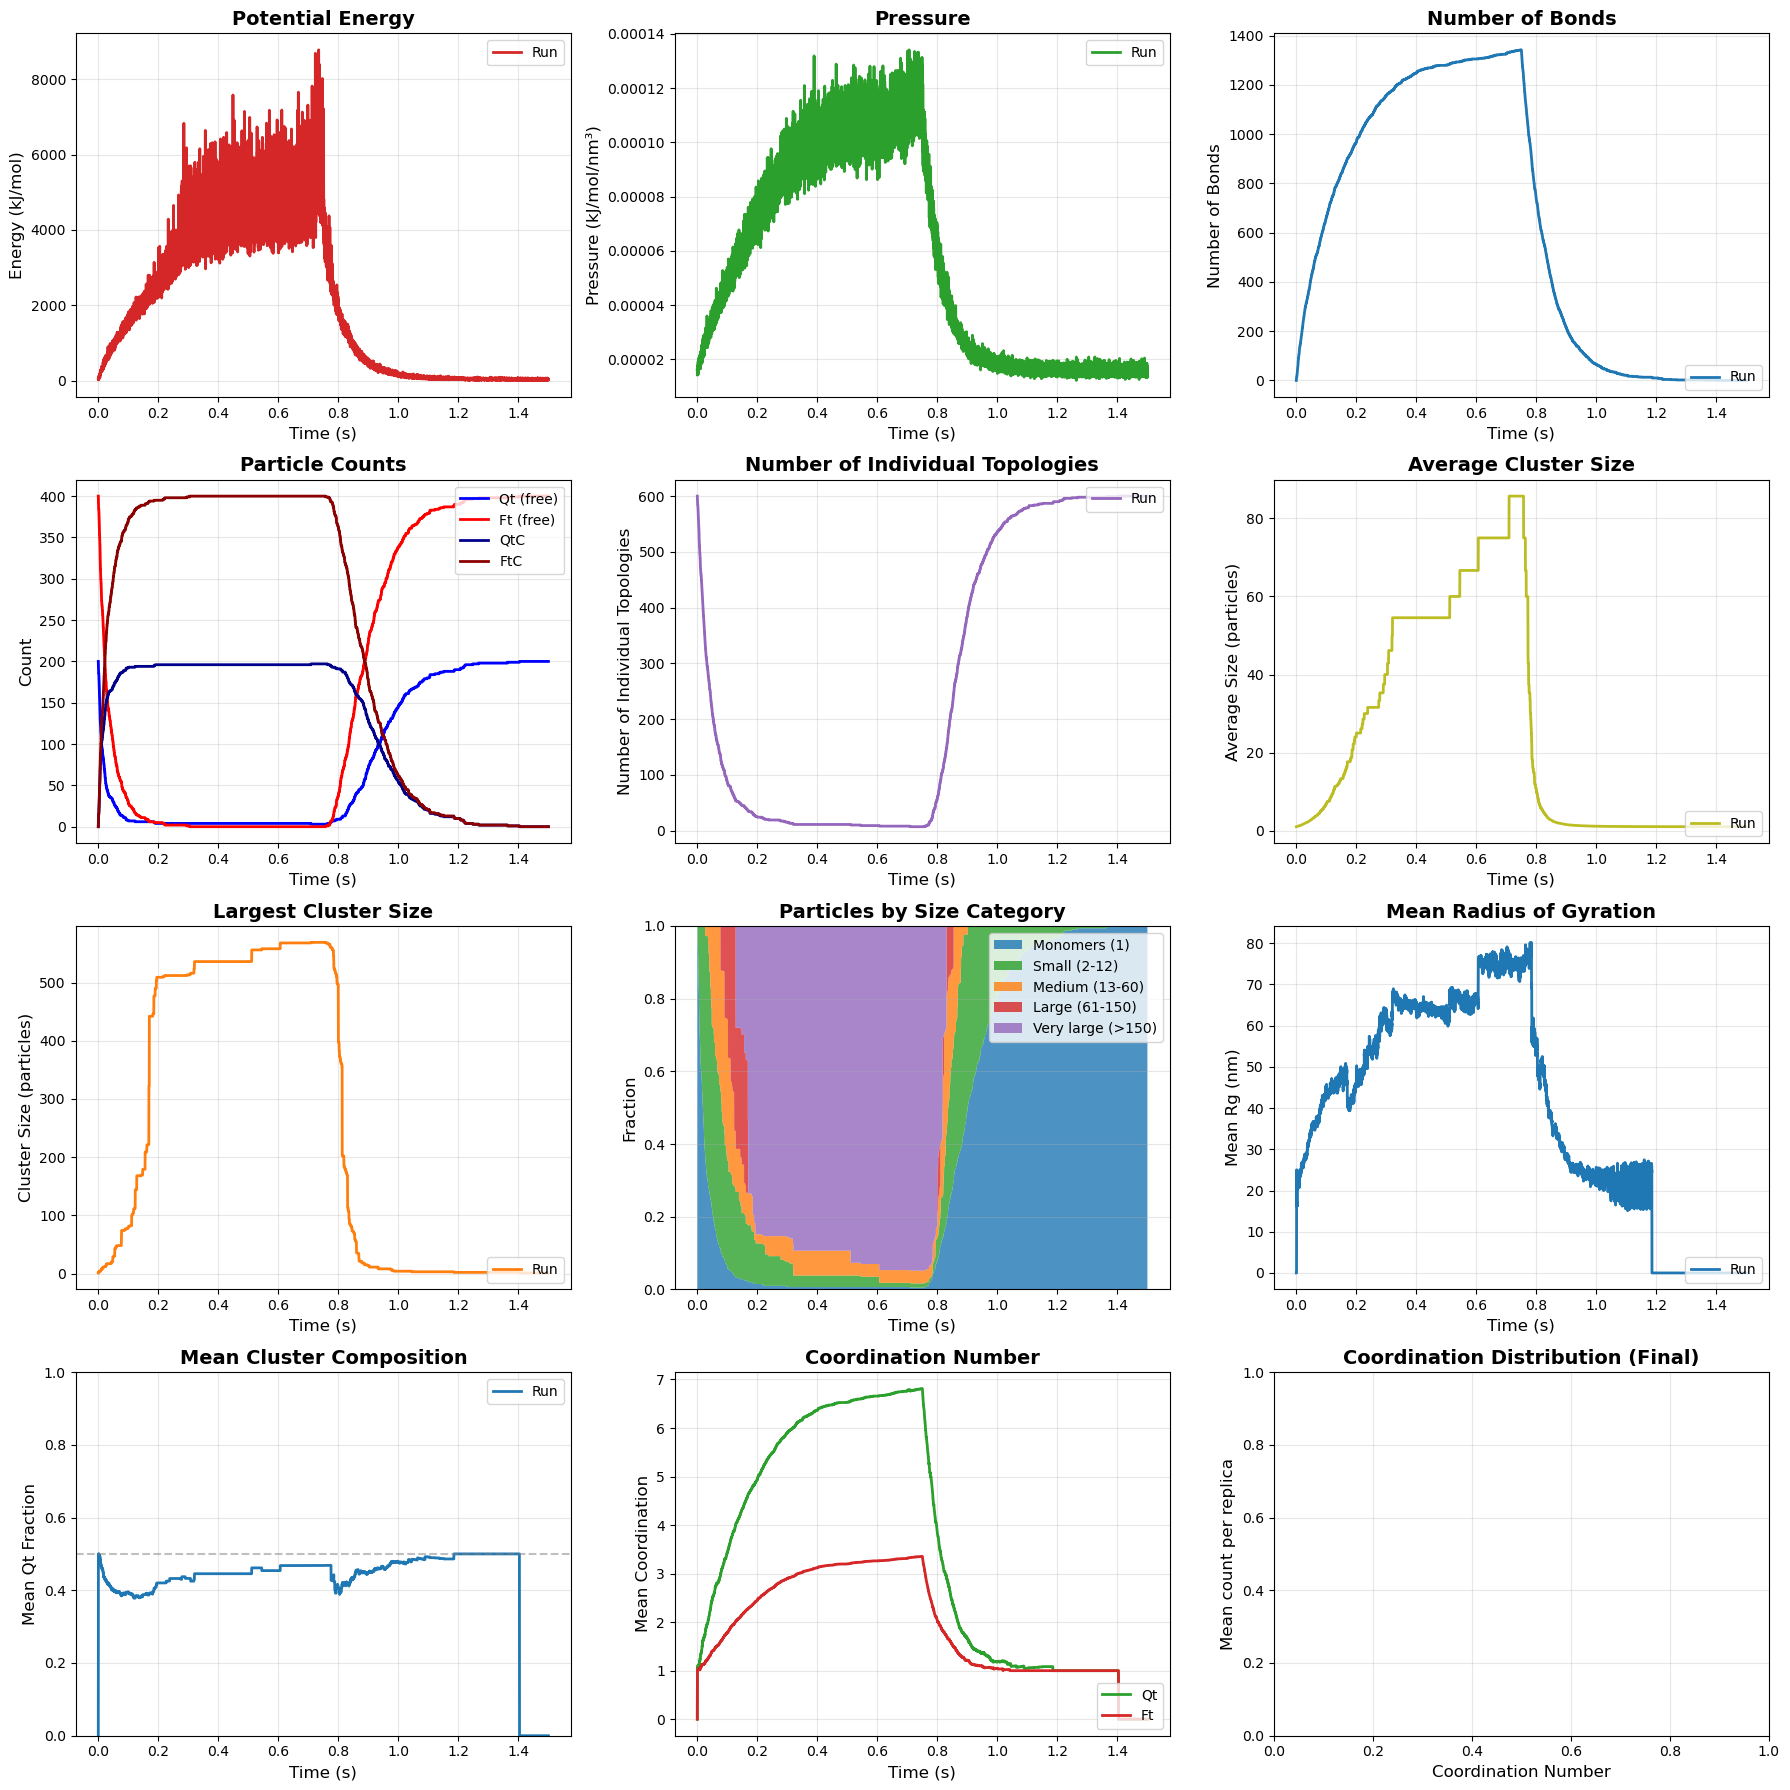

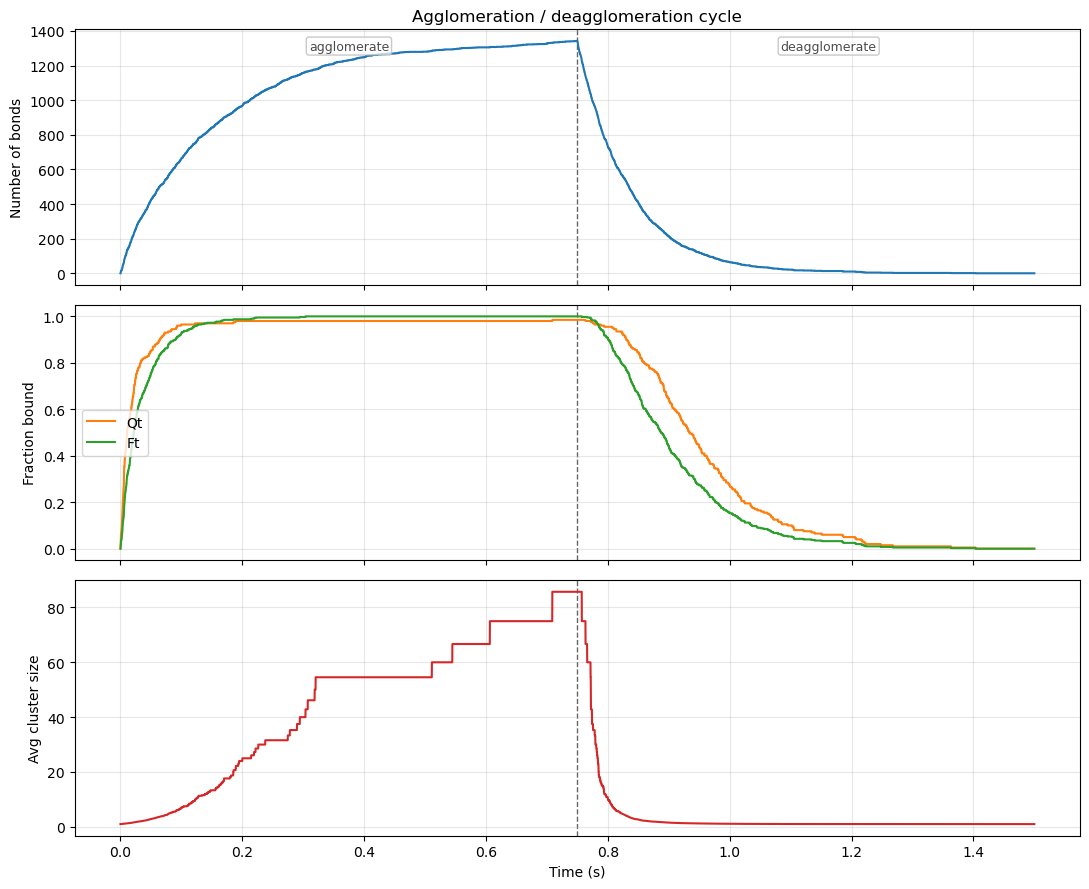

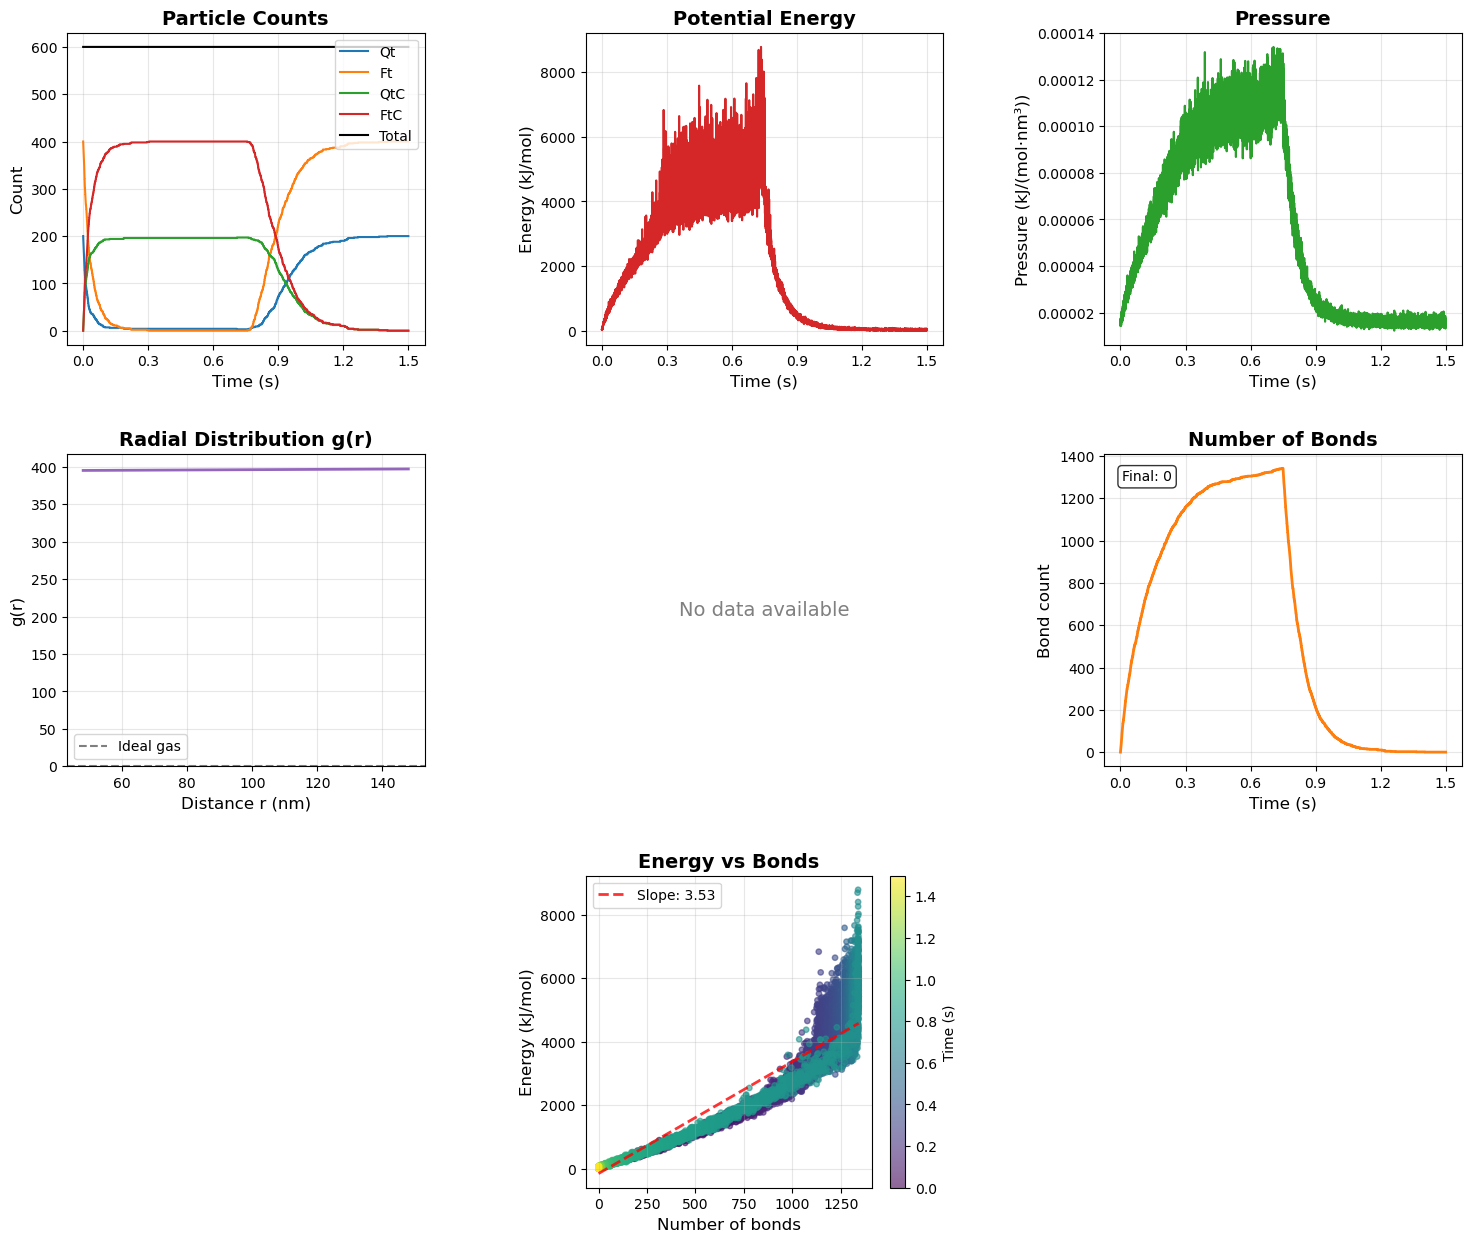

/home/befe/readdySimulations/Qt_Ft_Simulation_Github/qtft/plotting.py:1208: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  ax.axis("off")


✓ Saved plot to Simulation_Files_Single_Runs/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_phases2_kon1e-06_aggsteps750000_koff1.2e-08_deaggsteps750000_dt1us_1.5s_loops/Plots/clusters.svg


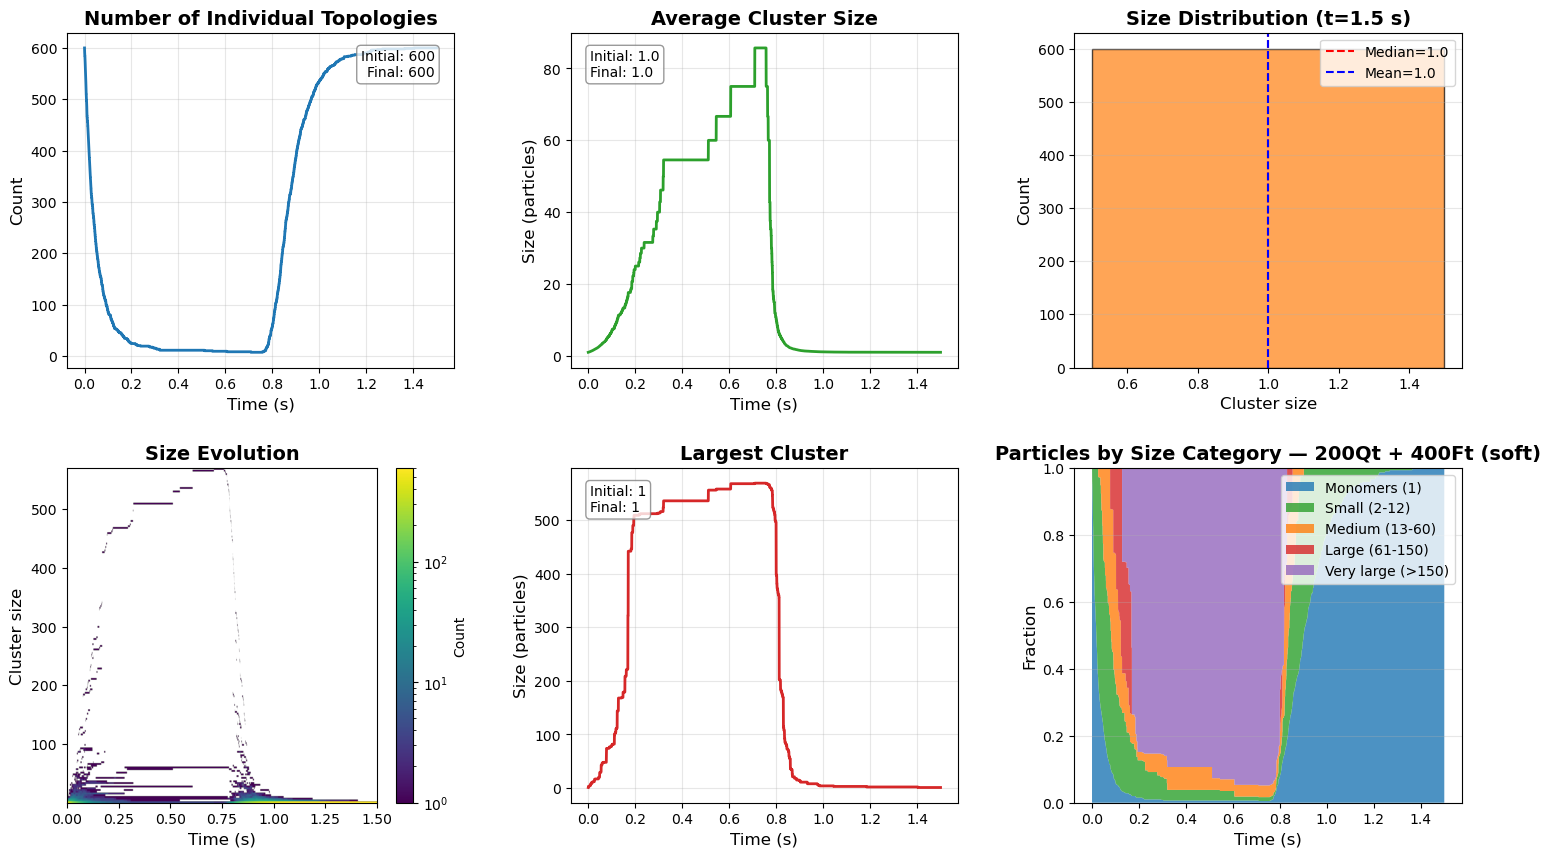


COMPUTING STRUCTURAL CLUSTER ANALYSIS

[1/5] Extracting frame data...
    Using trajectory.read() for data extraction (particles observable not available)
    Reading trajectory frames...


    Loading trajectory: 100%|██████████| 15001/15001 [00:29<00:00, 514.36frame/s]


       Extracted 15001 frames

[2/5] Morphology analysis...


  Morphology: 100%|██████████| 15001/15001 [01:06<00:00, 225.78frame/s] 


[3/5] Binding kinetics analysis...


...


[5/5] Contact analysis...



  Contacts: 100%|██████████| 15001/15001 [00:07<00:00, 2102.71frame/s]



✓ Structural analysis complete

Generating structural analysis plots...


/home/befe/readdySimulations/Qt_Ft_Simulation_Github/qtft/plotting.py:626: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  Row 4 - Contacts:



✓ Saved plot to Simulation_Files_Single_Runs/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_phases2_kon1e-06_aggsteps750000_koff1.2e-08_deaggsteps750000_dt1us_1.5s_loops/Plots/structural.svg


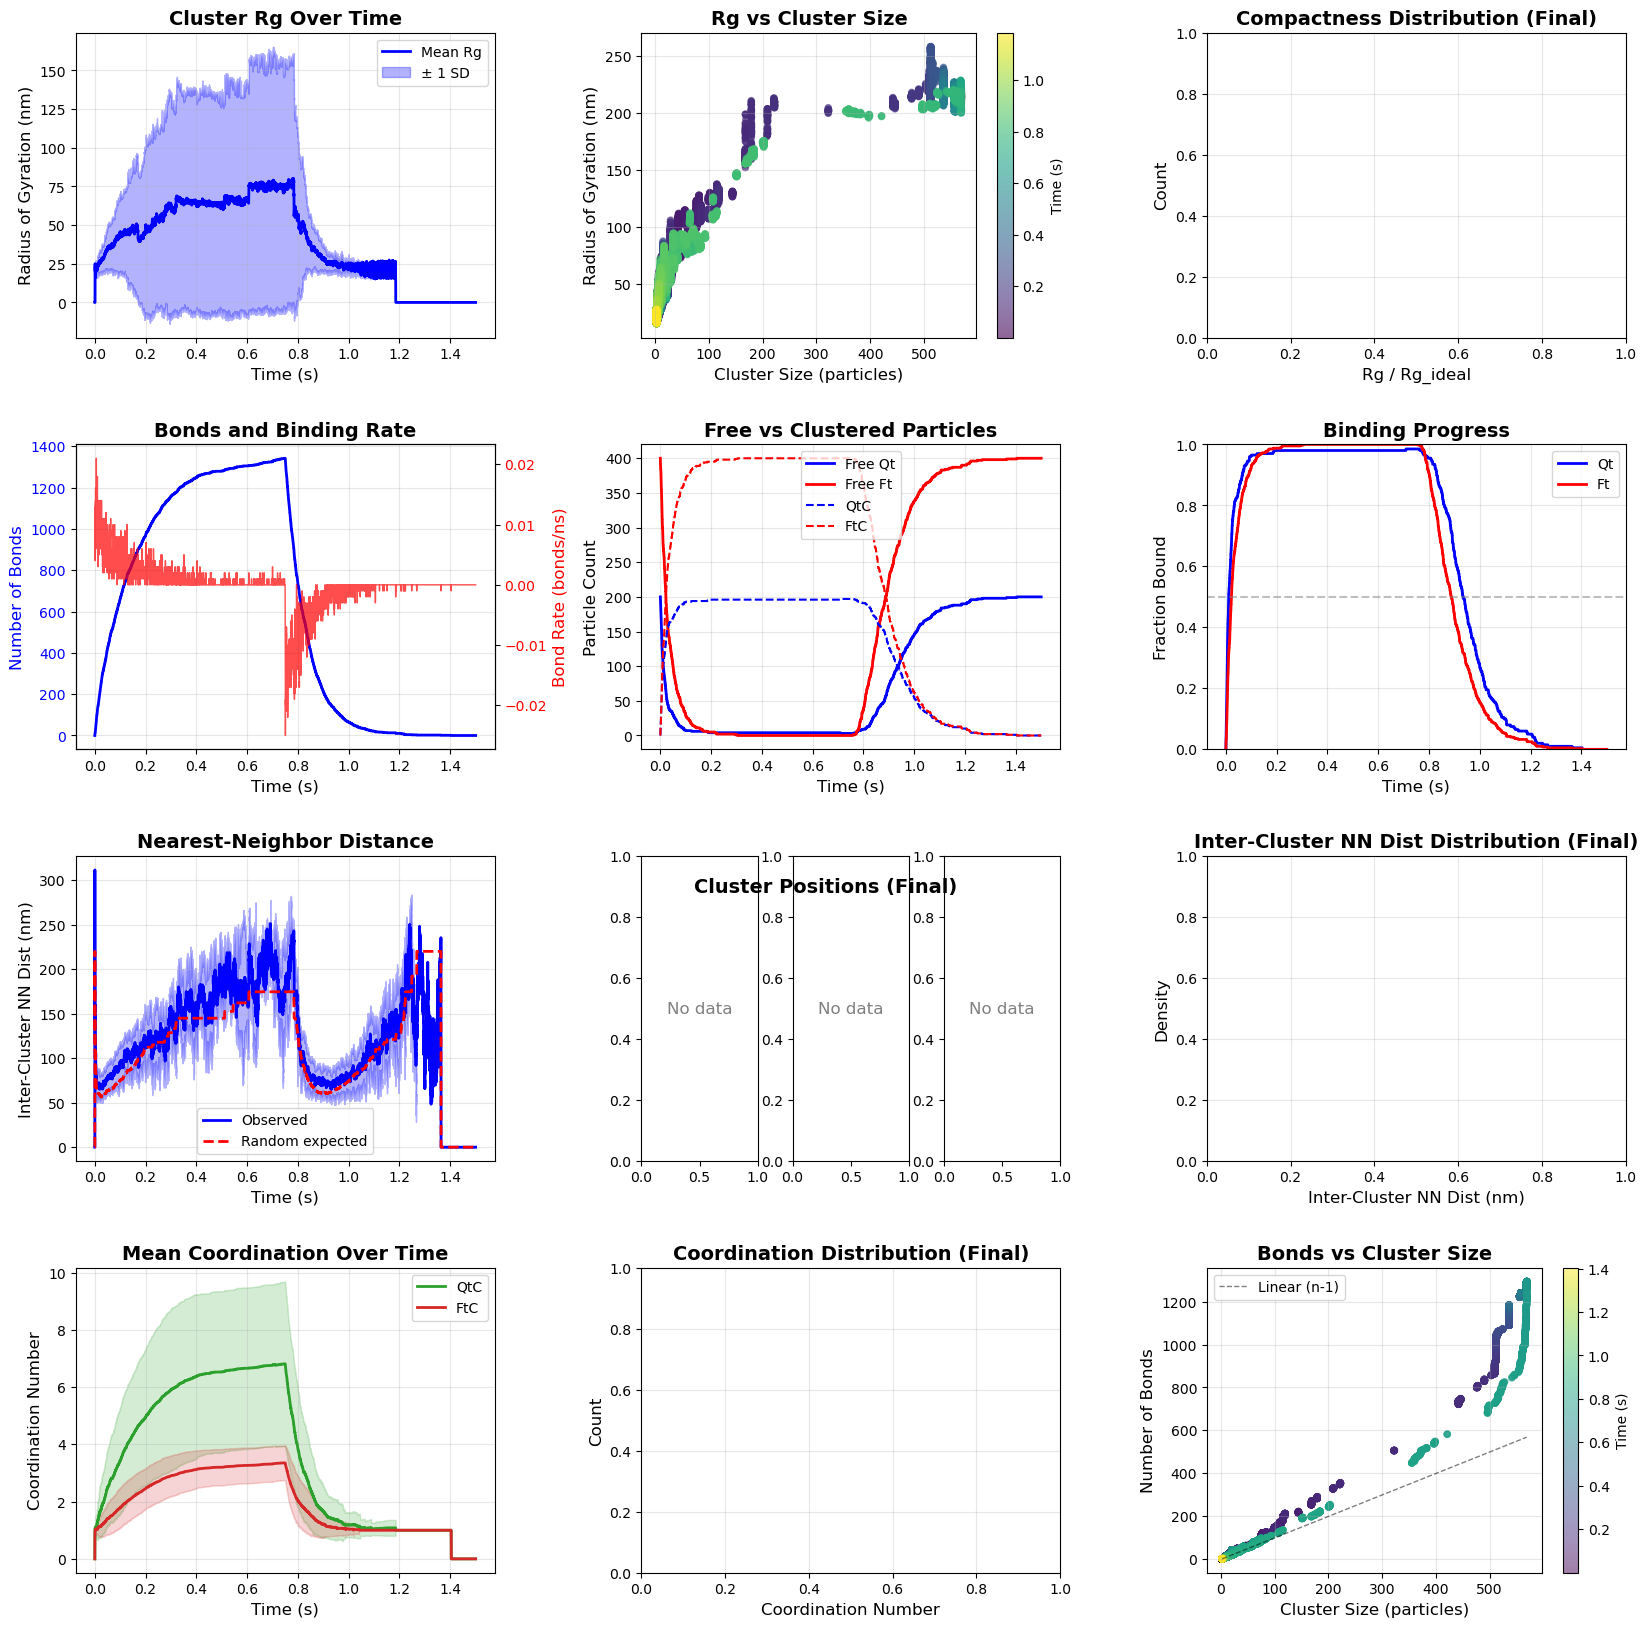


CLUSTER COMPOSITION ANALYSIS
  Extracting frame data for composition analysis...
    Using trajectory.read() for data extraction (particles observable not available)
    Reading trajectory frames...


  Composition: 100%|██████████| 15001/15001 [00:05<00:00, 2975.79frame/s]



Generating composition plots...

✓ Saved plot to Simulation_Files_Single_Runs/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_phases2_kon1e-06_aggsteps750000_koff1.2e-08_deaggsteps750000_dt1us_1.5s_loops/Plots/composition.svg


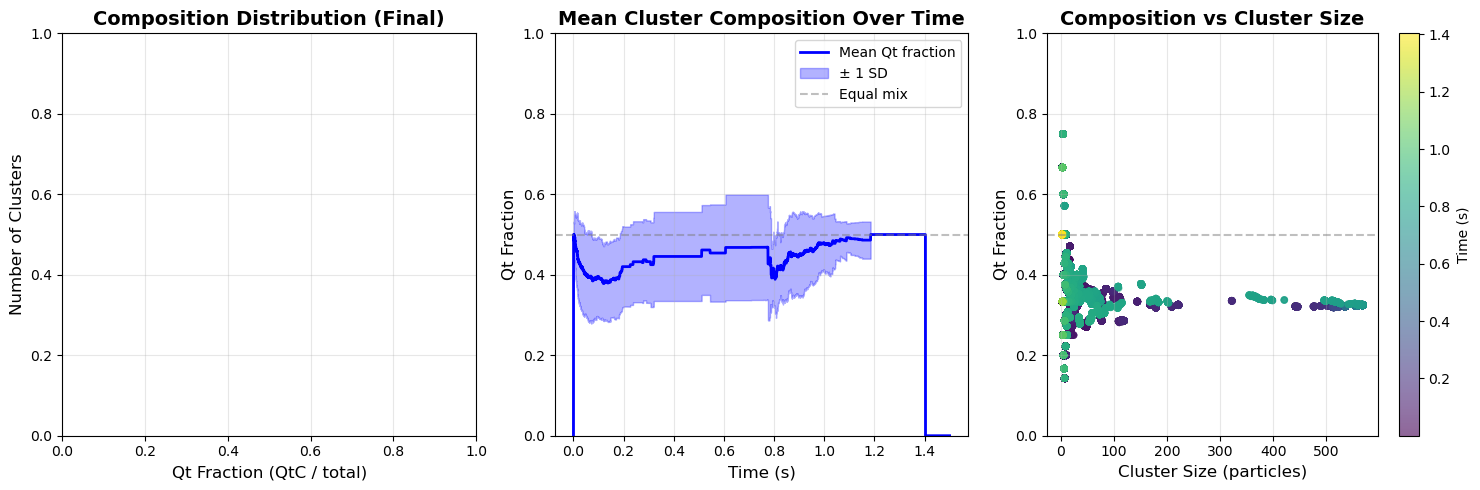


COMPOSITION ANALYSIS COMPLETE

  Bond counting: Method 1 (topology.edges) - exact count

SIMULATION RESULTS SUMMARY

Initial state (t=0):
  Topologies: 600
  Average size: 1.00 particles
  Largest: 1 particles
  Bonds: 0

Final state (t=1.5 s):
  Topologies: 600
  Average size: 1.00 particles
  Largest: 1 particles
  Bonds: 0

Final size distribution:
  Median: 1.0
  Mean: 1.0
  Std: 0.0
  Range: 1 - 1

Particle distribution:
  Monomers (1): 600 particles (100.0%)
  Small (2-12): 0 particles (0.0%)
  Medium (13-60): 0 particles (0.0%)
  Large (61-150): 0 particles (0.0%)
  Very large (>150): 0 particles (0.0%)

Saved time-series CSVs to Simulation_Files_Single_Runs/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_phases2_kon1e-06_aggsteps750000_koff1.2e-08_deaggsteps750000_dt1us_1.5s_loops/Plots/


In [25]:
# ============================================================
# RUN  —  plots + summary + data export, all driven by MODE
# ============================================================

if MODE == "single":
    run_name = os.path.basename(os.path.normpath(SINGLE_RUN_DIR))
    cfg_path = SINGLE_CONFIG or os.path.join(SINGLE_RUN_DIR, run_name + "_config.json")
    cfg = SimulationConfig.load_json(cfg_path)

    if SINGLE_H5:
        h5 = SINGLE_H5
    elif cfg.phases:
        h5 = os.path.join(SINGLE_RUN_DIR, "trajectory_combined.h5")
    else:
        h5 = os.path.join(SINGLE_RUN_DIR, run_name + ".h5")

    OUT = os.path.join(SINGLE_RUN_DIR, "Plots")
    os.makedirs(OUT, exist_ok=True)
    print(f"Single run: {h5}\nPlots/exports -> {OUT}/\n")

    # ----- Plots -----
    # (a) Overview panel — same 12 metrics the ensemble panel shows.
    stats1, struct1, cfg1 = analysis.build_single_run_plotting_data(h5, cfg, stride=STRIDE)
    plotting.plot_ensemble_panel(stats1, struct1, cfg1,
                                 save_path_base=os.path.join(OUT, "run_panel"))

    # (b) Compact kinetics figure (bonds / fraction bound / avg cluster size).
    if cfg.phases:
        phase_files = sorted(glob.glob(os.path.join(SINGLE_RUN_DIR, "phase_*", "trajectory.h5")))
        kin_data = analysis.load_phased_observables(cfg, phase_files=phase_files or None)
        kin_title = None   # default: "Agglomeration / deagglomeration cycle"
    else:
        kin_data = analysis.build_kinetics_data_single(h5, cfg)
        kin_title = "Agglomeration kinetics"
    plotting.plot_phased_kinetics(cfg, data=kin_data, title=kin_title,
                                  save_path=os.path.join(OUT, "kinetics.svg"))

    # (c) Detailed figures — now for phased runs too (they read trajectory_combined.h5).
    plotting.plot_observables(h5, cfg, save_path=os.path.join(OUT, "observables.svg"))
    plotting.plot_cluster_analysis(h5, cfg, save_path=os.path.join(OUT, "clusters.svg"))
    plotting.plot_structural_cluster_analysis(h5, cfg, stride=STRIDE,
                                              save_path=os.path.join(OUT, "structural.svg"))
    plotting.plot_cluster_composition(h5, cfg, stride=STRIDE,
                                      save_path=os.path.join(OUT, "composition.svg"))
    plt.show()

    # ----- Summary -----
    analysis.print_analysis_summary(h5, cfg)

    # ----- Data export (single runs have no ensemble-style table) -----
    cstats = analysis.get_cluster_statistics(h5)
    bonds  = analysis.get_bond_counts(h5, silent=True)
    f = cfg.timestep * 1e-3   # steps -> µs
    pd.DataFrame({
        "time_steps": cstats["times"],
        "time_us":    np.asarray(cstats["times"]) * f,
        "n_clusters": cstats["n_clusters"],
        "avg_size":   cstats["avg_sizes"],
        "max_size":   cstats["max_sizes"],
    }).to_csv(os.path.join(OUT, run_name + "_clusters.csv"), index=False)
    pd.DataFrame({
        "time_steps": bonds["times"],
        "time_us":    np.asarray(bonds["times"]) * f,
        "n_bonds":    bonds["n_bonds"],
    }).to_csv(os.path.join(OUT, run_name + "_bonds.csv"), index=False)
    print(f"Saved time-series CSVs to {OUT}/")

    if EXPORT_XYZ:
        xyz = os.path.join(OUT, run_name + ".xyz")
        analysis.convert_h5_to_xyz(h5, xyz, cfg, overwrite=True)
        print(f"Exported XYZ: {xyz}")

elif MODE == "ensemble":
    stats, structural, config = analysis.load_ensemble_data(ENSEMBLE_DIR)
    OUT = os.path.join(ENSEMBLE_DIR, "Plots")
    os.makedirs(OUT, exist_ok=True)
    print(f"Ensemble: {ENSEMBLE_DIR}\nPlots/exports -> {OUT}/\n")

    # ----- Plot (composite thesis panel: SVG + PNG) -----
    plotting.plot_ensemble_panel(stats, structural, config,
                               show_individual=SHOW_INDIVIDUAL,
                               save_path_base=os.path.join(OUT, "ensemble_panel"))

    # Second figure: the compact kinetics view, from replica means. Phased runs only —
    # for a plain ensemble the panel already carries these curves.
    if config.get("phases"):
        kin_data = analysis.build_kinetics_data_ensemble(stats, config)
        plotting.plot_phased_kinetics(config, data=kin_data,
                                      save_path=os.path.join(OUT, "ensemble_kinetics.svg"))
    plt.show()

    # ----- Summary -----
    analysis.print_ensemble_summary(stats, config)

    # ----- Data export: final-state table (.csv/.tex) + bonds time series -----
    df_summary = analysis.build_final_state_table(stats, config, structural)
    analysis.save_table_files(df_summary, os.path.join(OUT, "final_state_table"),
                              caption="Final-state summary (mean ± SD over replicas).",
                              label="tab:final_state")
    if "times" in stats and "bonds_mean" in stats:
        f = config.get("timestep", 0.001) * 1e-3
        pd.DataFrame({
            "time_steps": stats["times"],
            "time_us":    np.asarray(stats["times"]) * f,
            "bonds_mean": stats["bonds_mean"],
            "bonds_std":  stats.get("bonds_std", np.zeros_like(stats["bonds_mean"])),
        }).to_csv(os.path.join(OUT, "ensemble_bonds.csv"), index=False)
    print(f"Saved tables/CSV to {OUT}/")
    try:
        display(df_summary)
    except NameError:
        print(df_summary)

elif MODE == "comparison":
    comp = ae.compare_ensembles(ENSEMBLES_TO_COMPARE)
    _labels = "_".join(l.replace(" ", "") for l in comp["labels"])
    OUT = os.path.join(BASE_DIR, "Plots_Comparison_" + _labels)
    os.makedirs(OUT, exist_ok=True)
    print(f"Comparison of {comp['n_ensembles']} ensembles\nPlots/exports -> {OUT}/\n")

    # ----- Plots: comparison panel (SVG + PNG) + per-ensemble size categories -----
    plotting.plot_comparison_panel(comp, show_bands=SHOW_BANDS,
                                 save_path_base=os.path.join(OUT, "comparison_panel"))
    plotting.plot_comparison_size_categories(comp, save_dir=OUT)
    plt.show()

    # ----- Summary -----
    ae.print_parameter_differences(comp)

    # ----- Data export: comparison table (.csv/.tex) + raw comparison data -----
    df_compare = ae.build_comparison_table(comp)
    analysis.save_table_files(df_compare, os.path.join(OUT, "comparison_table"),
                              caption="Final-state comparison across ensembles (mean ± SD).",
                              label="tab:comparison")
    ae.save_comparison_data(comp, os.path.join(OUT, "comparison_data"))
    print(f"Saved tables/data to {OUT}/")
    try:
        display(df_compare)
    except NameError:
        print(df_compare)

else:
    raise ValueError(f"MODE must be 'single', 'ensemble', or 'comparison', got {MODE!r}")